# Modeling Forgetting with Artificial Neurons

## Model 1: Passive Memory Decay

We begin by modeling a memory  as an association (ex. APPLE -> RED) with strength 'w'.

We assume that memory strength decays at a rate proportional to its current strength:

dw/dt = -ƛw

Solving the differential equation gives:

w(t) = w₀e^(-ƛt)

where:
- w₀ is the initial memory strength
- ƛ is the decay rate
- t is the elapsed time
- w: [0, 1]

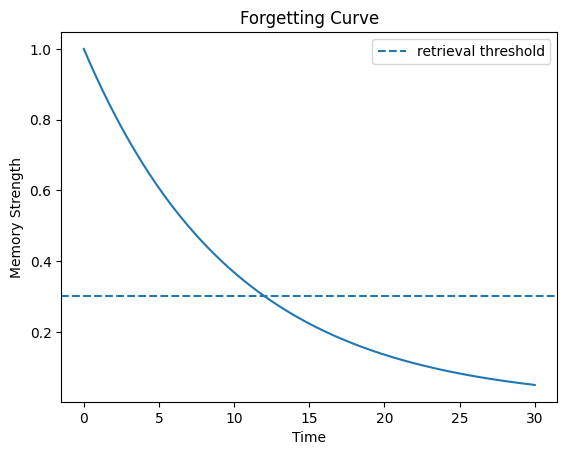

In [1]:
import numpy as np
import matplotlib.pyplot as plt

w0 = 1.0
decay_rate = 0.1
retrieval_threshold = 0.3

time = np.linspace(0, 30, 300)  # Time from 0 to 30 seconds, with 300 points

memory_strength = w0 * np.exp(-decay_rate * time)

retrieved = memory_strength >= retrieval_threshold

plt.plot(time, memory_strength)
plt.axhline(y=retrieval_threshold, linestyle='--', label='retrieval threshold')

plt.xlabel("Time")
plt.ylabel("Memory Strength")
plt.title("Forgetting Curve")
plt.legend()

plt.show()





## Model 2: Memory Reinforcement

The baseline model assumes that a memory passively decays over time. However, memories can be strengthened through review or retrieval.

To model reinforcement, a review at time t increases the synaptic weight according to:

w_new = w + ⍺(1 - w)

where ⍺ is the learning rate. The term (1 - w) represents the remaining capacity for the memory to strengthen, preventing the weight from exceeding 1.

Between reviews, the memory continues to decay exponentially.

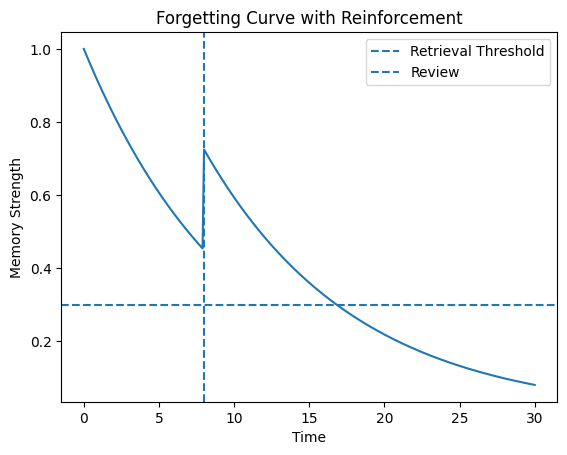

In [2]:
review_time = 8
learning_rate = 0.5

time = np.linspace(0, 30, 301)
dt = time[1]-time[0]

memory_strength = np.zeros(len(time))
memory_strength[0] = 1.0  # Initial memory strength

for i in range(1, len(time)):
    memory_strength[i] = memory_strength[i-1] * np.exp(-decay_rate * dt)

    if time[i-1] < review_time <= time[i]:
        memory_strength[i] = memory_strength[i] + learning_rate * (1 - memory_strength[i])

plt.plot(time, memory_strength)
plt.axhline(y=retrieval_threshold, linestyle='--', label='Retrieval Threshold')
plt.axvline(x=review_time, linestyle='--', label='Review')

plt.xlabel('Time')
plt.ylabel('Memory Strength')
plt.title('Forgetting Curve with Reinforcement')
plt.legend()

plt.show()



## Model 3: Spaced Repetition

Now, we'd like to model how our memory strength over time if we utilize spaced repitition, meaning we reinforce the memory in discrete time steps.

We predict that the memory will stay above the retrieval threshold, meaning we're able to recall it, for a longer amount of time.

We are utilizing the same equations and assumptions as above, where the memory continues to decay exponentially between each memory reinforcement.

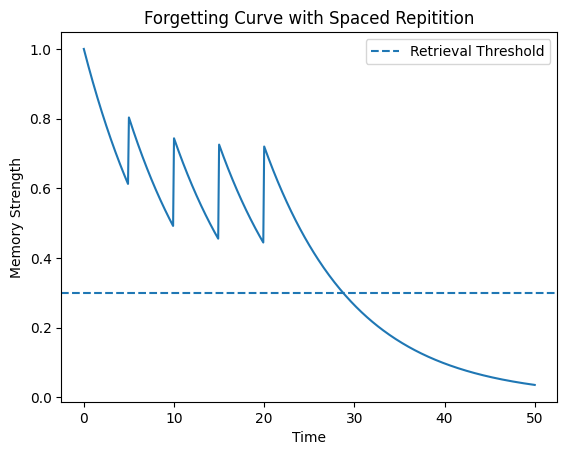

In [3]:
learning_rate = 0.5
review_time_start = 5
review_time_end = 20
time_step = 5
review_time = review_time_start

time = np.linspace(0, 50, 501)
dt = time[1]-time[0]

memory_strength = np.zeros(len(time))
memory_strength[0] = 1.0

for i in range(1, len(time)):
    memory_strength[i] = memory_strength[i-1] * np.exp(-decay_rate * dt)

    if time[i-1] < review_time <= time[i]:
        memory_strength[i] = memory_strength[i] + learning_rate * (1 - memory_strength[i])
        
        if review_time < review_time_end:
            review_time += time_step

plt.plot(time, memory_strength)
plt.axhline(y=retrieval_threshold, linestyle='--', label='Retrieval Threshold')

plt.xlabel('Time')
plt.ylabel('Memory Strength')
plt.title('Forgetting Curve with Spaced Repitition')
plt.legend()

plt.show()


### Interpretation of Model 3

As seen by the graph above, spaced repetition allows for the memory strength to stay above the retrieval threshold for longer.

Next, we'll explore the question: What if successful reinforcement doesn't merely increase w, but also makes the memory decay more slowly afterward?

## Model 4: Memory Consolidation

Repeated reinforcement may do more than temporarily increase memory strength. It may also make the memory more resistant to future decay.

To model this, we allow the decay rate ƛ to decrease after each successful review:

ƛ_new = ƛ * c

where c is a consolidation factor between 0 and 1.

We predict taht repeated reviews will produce increasingly stable memories, allowing review intervals to become longer over time.

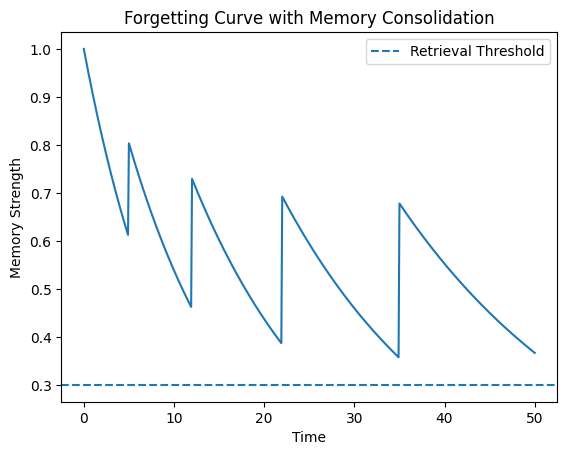

In [4]:
learning_rate = 0.5
initial_decay_rate = 0.1
decay_rate = initial_decay_rate
consolidation_factor = 0.8

review_times = [5, 12, 22, 35]
next_review_index = 0

time = np.linspace(0, 50, 501)
dt = time[1] - time[0]

memory_strength = np.zeros(len(time))
memory_strength[0] = 1.0

for i in range(1, len(time)):
    memory_strength[i] = memory_strength[i - 1] * np.exp(-decay_rate * dt)

    if next_review_index < len(review_times):
        review_time = review_times[next_review_index]

        if time[i - 1] < review_time <= time[i]:
            memory_strength[i] = memory_strength[i] + learning_rate * (1 - memory_strength[i])
            decay_rate *= consolidation_factor
            next_review_index += 1

        
plt.plot(time, memory_strength)
plt.axhline(y=retrieval_threshold, linestyle='--', label='Retrieval Threshold')

plt.xlabel('Time')
plt.ylabel('Memory Strength')
plt.title('Forgetting Curve with Memory Consolidation')
plt.legend()

plt.show()


### Interpretation of Model 4

Model 4 demonstrates that reducing the decay rate after successful reinforcement allows increasingly spaced reviews to maintain the memory above the retrieval threshold.

Note: this behavior follows assumption built into the model and should not be interpreted as evidence that biological memory follows these exact equations.

## Model 5: Memory Interference

Memories decaying over time isn't the only way forgetting can occur. If you learn something new corresponding to the same association you had before, that will negatively impact the strength of the first memory.

We model two competing memories that share the same input neuron:

APPLE -> RED
APPLE -> GREEN

When a competing association is learned, the original memory is weakened according to:

w_old,new = w_old * (1 - β)

where β represents the strength of interference.

We predict that stronger interference will reduce the retrievability of the original memory.

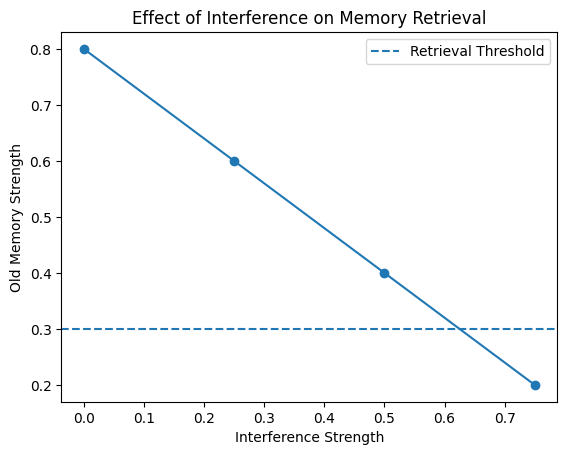

In [5]:
old_memory = 0.8
interference_strengths = [0.0, 0.25, 0.5, 0.75]

remaining_strengths = []

for beta in interference_strengths:
    weakened_memory = old_memory * (1 - beta)
    remaining_strengths.append(weakened_memory)

plt.plot(interference_strengths, remaining_strengths, marker='o')
plt.axhline(y=retrieval_threshold, linestyle='--', label='Retrieval Threshold')

plt.xlabel("Interference Strength")
plt.ylabel("Old Memory Strength")
plt.title("Effect of Interference on Memory Retrieval")
plt.legend()
plt.show()

### Interpretation of Model 5

Model 5 demonstrates the negative linear relationship between the strength of the interference and the remaining strength of the old memory. This trend makes sense because the higher the interference strength, the more impact the new memory has on the retrievability of the old memory. Therefore, the old memory strength gets lower as the interference strength gets higher.

## Model 6: Competitive Retrieval

Instead of directly weakening the old memory, we'll have one cue neuron feeding two output neurons:

APPLE -> w_red -> RED
      -> w_green -> GREEN

Whichever output has the larger activation wins.

In [6]:
input_activation = 1.0

w_red = 0.8
w_green = 0.2
retrieved_memory = ''

learning_rate = 0.5
w_green += learning_rate * (1 - w_green)

red_activation = w_red * input_activation
green_activation = w_green * input_activation

if red_activation > green_activation:
    retrieved_memory = 'RED'
elif green_activation > red_activation:
    retrieved_memory = 'GREEN'
else:
    retrieved_memory = 'AMBIGUOUS'

print(retrieved_memory)


RED


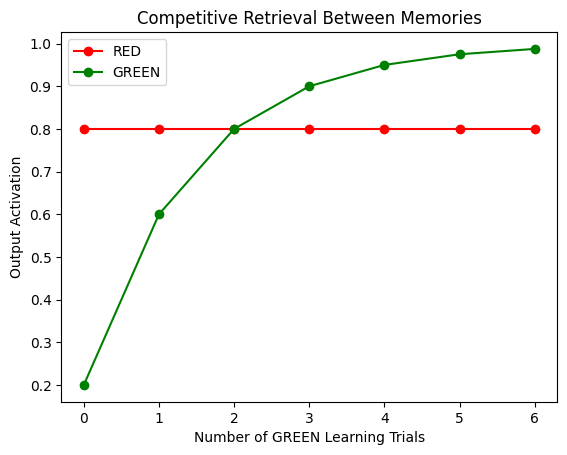

In [7]:
w_red = 0.8
w_green = 0.2
learning_rate = 0.5

num_trials = 6

red_activations = []
green_activations = []

for trial in range(num_trials + 1):
    red_activation = w_red * input_activation
    green_activation = w_green * input_activation

    red_activations.append(red_activation)
    green_activations.append(green_activation)

    w_green += learning_rate * (1 - w_green)

trials = range(num_trials + 1)

plt.plot(trials, red_activations, marker='o', label='RED', color='red')
plt.plot(trials, green_activations, marker='o', label='GREEN', color='green')

plt.xlabel('Number of GREEN Learning Trials')
plt.ylabel('Output Activation')
plt.title('Competitive Retrieval Between Memories')
plt.legend()
plt.show()

### Interpretation of Model 6

Model 6 demonstrates that after repeatedly learning, the output activation of the green neuron surpasses that of the red neuron despite starting signifcantly lower.

There's an important detail here: the weight connecting the cue nueron to the red output neuron never changed - it remained at 0.8.

Therefore, this model represents forgetting through retrieval competition rather than memory decay or destruction. Both output neurons can still be activated, but depending on their connection weights, one produces a greater activation and its associated memory wins the retrieval competition.